# FL-MTKD with DFT Reparameterization - COVID-19 CT Scans

This notebook runs the DFT reparameterization compression on the **COVID-19 CT scan dataset**
for fair comparison with the entropy-penalized approach.

Based on: Oktay et al., "Scalable Model Compression by Entropy Penalized Reparameterization" (ICLR 2020)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")

2026-02-12 21:11:15.646680: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 21:11:15.647221: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 21:11:15.650044: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 21:11:15.684246: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 21:11:16.337723: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

TensorFlow version: 2.16.1
GPUs available: 0


2026-02-12 21:11:18.104617: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Configuration (Same as FL_MTKD_with_compression)

In [2]:
# Model and training configuration - SAME AS ORIGINAL
IMAGE_SIZE = 200  # COVID-19 CT scan size
NUM_CLASSES = 2   # COVID-19 vs Non-COVID-19
BATCH_SIZE = 32
NUM_EPOCHS = 5
NUM_ROUNDS = 50
NUM_CLIENTS = 3

# DFT Compression hyperparameters
LAMBDA_RATE = 0.0001  # Rate-distortion trade-off
LEARNING_RATE = 0.001
TEMPERATURE = 3.0
ALPHA = 0.5

CLASSES = ['COVID-19', 'Non-COVID-19']
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)

## 2. Load COVID-19 CT Scan Data (Same as original notebook)

In [3]:
# Data paths - try multiple locations
possible_base_paths = [
    Path('/home/maxwellsam/Compression_Model_FL_MTKD/data'),  # Original server path
    Path('/Users/maxwellsam/Documents/FL_MTKD-Compression/data'),  # Local Mac path
    Path('./data'),  # Relative path
    Path('../data'),
]

def find_data_path():
    for base_path in possible_base_paths:
        dataset1_path = base_path / 'Dataset1' / 'Dataset1_input.npy'
        if dataset1_path.exists():
            print(f"Found data at: {base_path}")
            return base_path
    
    # List what we can find
    print("Could not find data. Searching for .npy files...")
    for p in possible_base_paths:
        if p.exists():
            npy_files = list(p.rglob('*.npy'))
            if npy_files:
                print(f"Found in {p}: {[str(f) for f in npy_files[:5]]}...")
    return None

DATA_PATH = find_data_path()

if DATA_PATH is None:
    print("\nPlease update the data path. Looking for:")
    print("  - Dataset1/Dataset1_input.npy")
    print("  - Dataset1/Dataset1_output.npy")
    print("  - Dataset2/Dataset2_input.npy")
    print("  - Dataset2/Dataset2_output.npy")
    print("  - Dataset3/Dataset3_input.npy")
    print("  - Dataset3/Dataset3_output.npy")

Found data at: /home/maxwellsam/Compression_Model_FL_MTKD/data


In [4]:
# Load the COVID-19 CT scan datasets
print("Loading COVID-19 CT scan datasets...")

# Dataset 1
input_data_x_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_input.npy'))
output_label_y_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_output.npy'))

# Dataset 2
input_data_x_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_input.npy'))
output_label_y_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_output.npy'))

# Dataset 3
input_data_x_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_input.npy'))
output_label_y_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_output.npy'))

print('------------------ DATASET 1 ---------------------')
print(f'Input_x Data Shape: {input_data_x_load.shape}')
print(f'Output_y Data Shape: {output_label_y_load.shape}')

print('------------------ DATASET 2 ---------------------')
print(f'Input_x Data Shape: {input_data_x_2_load.shape}')
print(f'Output_y Data Shape: {output_label_y_2_load.shape}')

print('------------------ DATASET 3 ---------------------')
print(f'Input_x Data Shape: {input_data_x_3_load.shape}')
print(f'Output_y Data Shape: {output_label_y_3_load.shape}')

Loading COVID-19 CT scan datasets...
------------------ DATASET 1 ---------------------
Input_x Data Shape: (4649, 200, 200, 1)
Output_y Data Shape: (4649, 2)
------------------ DATASET 2 ---------------------
Input_x Data Shape: (13980, 200, 200, 1)
Output_y Data Shape: (13980, 2)
------------------ DATASET 3 ---------------------
Input_x Data Shape: (13808, 200, 200, 1)
Output_y Data Shape: (13808, 2)


In [5]:
# Create federated client datasets (SAME AS ORIGINAL - Non-IID Unbalanced)
print("Creating federated client datasets (Non-IID Unbalanced)...")

# Client 1: Dataset 1 (indices 2501:3901)
train_features_dataset1_fed, test_features_dataset1_fed, train_labels_dataset1_fed, test_labels_dataset1_fed = train_test_split(
    input_data_x_load[2501:3901,:], output_label_y_load[2501:3901,:], test_size=.20, random_state=25)

# Client 2: Dataset 2 (indices 6501:10400)
train_features_dataset2_fed, test_features_dataset2_fed, train_labels_dataset2_fed, test_labels_dataset2_fed = train_test_split(
    input_data_x_2_load[6501:10400,:], output_label_y_2_load[6501:10400,:], test_size=.20, random_state=25)

# Client 3: Dataset 3 (indices 1201:end)
train_features_dataset3_fed, test_features_dataset3_fed, train_labels_dataset3_fed, test_labels_dataset3_fed = train_test_split(
    input_data_x_3_load[1201:,:], output_label_y_3_load[1201:,:], test_size=.20, random_state=25)

print(f'Client 1: train={train_features_dataset1_fed.shape}, test={test_features_dataset1_fed.shape}')
print(f'Client 2: train={train_features_dataset2_fed.shape}, test={test_features_dataset2_fed.shape}')
print(f'Client 3: train={train_features_dataset3_fed.shape}, test={test_features_dataset3_fed.shape}')

# Combined test set
x_test_combined = np.concatenate((test_features_dataset1_fed, test_features_dataset2_fed, test_features_dataset3_fed), axis=0)
y_test_combined = np.concatenate((test_labels_dataset1_fed, test_labels_dataset2_fed, test_labels_dataset3_fed), axis=0)
print(f'\nCombined test set: {x_test_combined.shape}, {y_test_combined.shape}')

Creating federated client datasets (Non-IID Unbalanced)...
Client 1: train=(1120, 200, 200, 1), test=(280, 200, 200, 1)
Client 2: train=(3119, 200, 200, 1), test=(780, 200, 200, 1)
Client 3: train=(10085, 200, 200, 1), test=(2522, 200, 200, 1)

Combined test set: (3582, 200, 200, 1), (3582, 2)


In [6]:
# Create client data list and TF datasets
client_data = [
    (train_features_dataset1_fed, train_labels_dataset1_fed),
    (train_features_dataset2_fed, train_labels_dataset2_fed),
    (train_features_dataset3_fed, train_labels_dataset3_fed)
]

def create_tf_dataset_for_client(client_dataset):
    client_images, client_labels = client_dataset
    dataset = tf.data.Dataset.from_tensor_slices((client_images, client_labels))
    return dataset

def preprocess_dataset(dataset, batch_size=BATCH_SIZE, shuffle_buffer_size=10000):
    return dataset.shuffle(shuffle_buffer_size).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

client_datasets = [create_tf_dataset_for_client(data) for data in client_data]
federated_train_data = [preprocess_dataset(dataset) for dataset in client_datasets]

print(f"Created {len(federated_train_data)} federated client datasets")

Created 3 federated client datasets


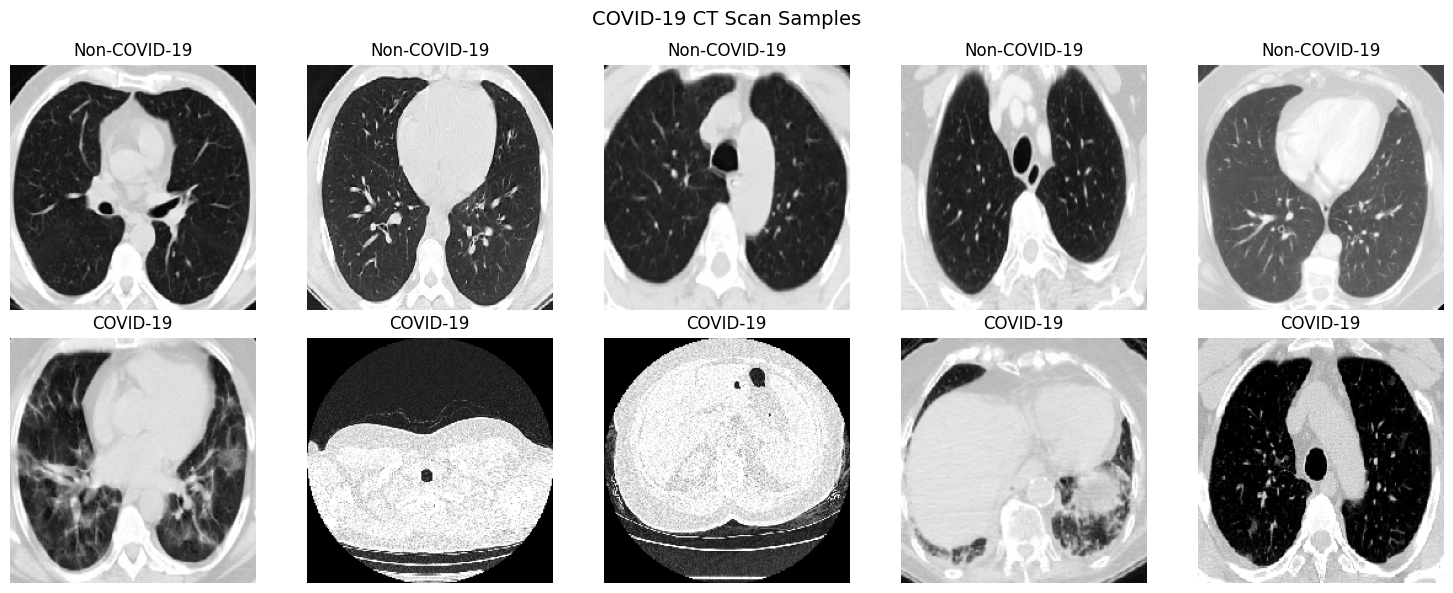

In [7]:
# Visualize some COVID-19 CT scan samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Get indices for each class
combined_train_x = np.concatenate([train_features_dataset1_fed, train_features_dataset2_fed, train_features_dataset3_fed])
combined_train_y = np.concatenate([train_labels_dataset1_fed, train_labels_dataset2_fed, train_labels_dataset3_fed])

class_0_idx = np.where(combined_train_y[:, 0] == 1)[0][:5] if combined_train_y.shape[1] > 1 else np.where(combined_train_y == 0)[0][:5]
class_1_idx = np.where(combined_train_y[:, 1] == 1)[0][:5] if combined_train_y.shape[1] > 1 else np.where(combined_train_y == 1)[0][:5]

for i in range(min(5, len(class_0_idx))):
    img = combined_train_x[class_0_idx[i]]
    if len(img.shape) == 3:
        img = img[:,:,0]
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('Non-COVID-19')
    axes[0, i].axis('off')

for i in range(min(5, len(class_1_idx))):
    img = combined_train_x[class_1_idx[i]]
    if len(img.shape) == 3:
        img = img[:,:,0]
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('COVID-19')
    axes[1, i].axis('off')

plt.suptitle('COVID-19 CT Scan Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 3. DFT Reparameterization Layers

In [8]:
class EntropyModel(tf.keras.layers.Layer):
    """Learned entropy model for estimating rate (bits) of latent parameters."""
    
    def __init__(self, num_filters=3, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self._built = False
        
    def build(self, input_shape):
        if self._built:
            return
        self.H = []
        self.b = []
        self.a = []
        
        filters = [1, self.num_filters, self.num_filters, self.num_filters, 1]
        
        for i in range(len(filters) - 1):
            init = tf.initializers.RandomUniform(minval=-0.5, maxval=0.5)
            self.H.append(self.add_weight(
                name=f'H_{i}', shape=(filters[i+1], filters[i]),
                initializer=init, trainable=False
            ))
            self.b.append(self.add_weight(
                name=f'b_{i}', shape=(filters[i+1], 1),
                initializer='zeros', trainable=False
            ))
            if i < len(filters) - 2:
                self.a.append(self.add_weight(
                    name=f'a_{i}', shape=(filters[i+1], 1),
                    initializer='zeros', trainable=False
                ))
        self._built = True
        super().build(input_shape)
    
    def _logits_cumulative(self, x):
        x = tf.reshape(x, (1, -1))
        for i, (H, b) in enumerate(zip(self.H, self.b)):
            x = tf.nn.softplus(H) @ x + b
            if i < len(self.a):
                x = x + tf.tanh(self.a[i]) * tf.tanh(x)
        return tf.squeeze(x, axis=0)
    
    def call(self, x, training=False):
        if not self._built:
            self.build(x.shape)
            
        x_flat = tf.reshape(x, [-1])
        if training:
            x_flat = x_flat + tf.random.uniform(tf.shape(x_flat), -0.5, 0.5)
        
        lower = self._logits_cumulative(x_flat - 0.5)
        upper = self._logits_cumulative(x_flat + 0.5)
        
        sign = tf.stop_gradient(tf.sign(lower + upper))
        sign = tf.where(tf.equal(sign, 0), tf.ones_like(sign), sign)
        
        likelihood = tf.abs(tf.sigmoid(sign * upper) - tf.sigmoid(sign * lower))
        likelihood = tf.maximum(likelihood, 1e-9)
        
        bits = -tf.math.log(likelihood) / tf.math.log(2.0)
        return tf.reduce_sum(bits)

In [9]:
def create_dft_matrix(n):
    """Create real-valued DFT basis matrix."""
    i = tf.range(n, dtype=tf.float32)
    j = tf.range(n, dtype=tf.float32)
    freq = 2.0 * np.pi * tf.reshape(i, [-1, 1]) * tf.reshape(j, [1, -1]) / tf.cast(n, tf.float32)
    dft_matrix = tf.cos(freq) / tf.sqrt(tf.cast(n, tf.float32))
    dft_matrix = dft_matrix / (tf.norm(dft_matrix, axis=1, keepdims=True) + 1e-8)
    return dft_matrix


class DFTConv2D(tf.keras.layers.Layer):
    """Convolutional layer with DFT reparameterization."""
    
    def __init__(self, filters, kernel_size, activation=None, lambda_rate=0.001, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.activation = tf.keras.activations.get(activation)
        self.lambda_rate = lambda_rate
        
    def build(self, input_shape):
        in_channels = input_shape[-1]
        kh, kw = self.kernel_size
        
        self.kernel_shape = (kh, kw, in_channels, self.filters)
        self.num_params = kh * kw * in_channels * self.filters
        
        self.theta = self.add_weight(
            name='theta', shape=(self.num_params,),
            initializer='glorot_normal', trainable=True
        )
        self.log_scales = self.add_weight(
            name='log_scales', shape=(self.num_params,),
            initializer=tf.initializers.Constant(-1.0), trainable=True
        )
        self.bias = self.add_weight(
            name='bias', shape=(self.filters,),
            initializer='zeros', trainable=True
        )
        
        self.dft_h = create_dft_matrix(kh)
        self.dft_w = create_dft_matrix(kw)
        
        self.entropy_model = EntropyModel()
        self.entropy_model.build((self.num_params,))
        
        super().build(input_shape)
    
    def get_kernel(self):
        scales = tf.exp(self.log_scales)
        scaled_theta = scales * self.theta
        theta_4d = tf.reshape(scaled_theta, self.kernel_shape)
        
        kernel = theta_4d
        kernel = tf.tensordot(tf.transpose(self.dft_h), kernel, axes=[[1], [0]])
        kernel = tf.tensordot(tf.transpose(self.dft_w), kernel, axes=[[1], [1]])
        kernel = tf.transpose(kernel, [1, 0, 2, 3])
        return kernel
    
    def compute_entropy_loss(self):
        bits = self.entropy_model(self.theta, training=True)
        return self.lambda_rate * bits
    
    def call(self, inputs, training=False):
        kernel = self.get_kernel()
        output = tf.nn.conv2d(inputs, kernel, strides=1, padding='VALID')
        output = tf.nn.bias_add(output, self.bias)
        if self.activation is not None:
            output = self.activation(output)
        return output


class DFTDense(tf.keras.layers.Layer):
    """Dense layer with learned linear reparameterization."""
    
    def __init__(self, units, activation=None, lambda_rate=0.001, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.lambda_rate = lambda_rate
        
    def build(self, input_shape):
        in_features = input_shape[-1]
        self.num_params = in_features * self.units
        self.weight_shape = (in_features, self.units)
        
        self.theta = self.add_weight(
            name='theta', shape=(self.num_params,),
            initializer='glorot_normal', trainable=True
        )
        self.log_scales = self.add_weight(
            name='log_scales', shape=(self.num_params,),
            initializer=tf.initializers.Constant(-1.0), trainable=True
        )
        self.bias = self.add_weight(
            name='bias', shape=(self.units,),
            initializer='zeros', trainable=True
        )
        
        self.entropy_model = EntropyModel()
        self.entropy_model.build((self.num_params,))
        
        super().build(input_shape)
    
    def get_kernel(self):
        scales = tf.exp(self.log_scales)
        scaled_theta = scales * self.theta
        return tf.reshape(scaled_theta, self.weight_shape)
    
    def compute_entropy_loss(self):
        bits = self.entropy_model(self.theta, training=True)
        return self.lambda_rate * bits
    
    def call(self, inputs, training=False):
        kernel = self.get_kernel()
        output = tf.matmul(inputs, kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

## 4. Create DFT Student Model (Same architecture as original)

In [10]:
def create_dft_student_model(lambda_rate=LAMBDA_RATE):
    """
    Create student model with DFT reparameterization.
    Architecture matches the original FL-MTKD student model.
    """
    inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
    
    # DFT-reparameterized Conv2D layer
    x = DFTConv2D(32, kernel_size=3, activation='relu', 
                  lambda_rate=lambda_rate, name='dft_conv')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    
    # DFT-reparameterized Dense layer
    x = DFTDense(NUM_CLASSES, lambda_rate=lambda_rate, name='dft_dense')(x)
    outputs = tf.keras.layers.Softmax()(x)
    
    model = tf.keras.Model(inputs, outputs, name='dft_student_covid19')
    return model


# Test model
test_model = create_dft_student_model()
test_model.summary()
print(f"\nInput shape: {(IMAGE_SIZE, IMAGE_SIZE, 1)}")
print(f"Output classes: {NUM_CLASSES}")

Model: "dft_student_covid19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dft_conv (DFTConv2D)            │ (None, 198, 198, 32)   │           651 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 313632)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dft_dense (DFTDense)            │ (None, 2)              │     1,254,573 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,255,224 (4.79 MB)

 Trainable params: 1,255,138 (4.79 MB)

 Non-trainable params: 86 (344.00 B)


Input shape: (200, 200, 1)
Output classes: 2


## 5. Teacher Models

In [11]:
def create_teacher_model(name):
    """Create a larger teacher model for COVID-19 classification."""
    return tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name=name)


def train_teacher_model(teacher, train_data, train_labels, epochs=5):
    """Train a teacher model."""
    x_train = train_data.astype(np.float32) / 255.0
    if len(x_train.shape) == 3:
        x_train = np.expand_dims(x_train, -1)
    
    # Ensure labels are float
    y_train = train_labels.astype(np.float32)
    
    teacher.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    teacher.fit(x_train, y_train, epochs=epochs, batch_size=32, 
                validation_split=0.1, verbose=1)
    return teacher


# Train teachers on each client's data
print("Training teacher models on COVID-19 CT scan data...\n")
teachers = []
teacher_train_data = [
    (train_features_dataset1_fed, train_labels_dataset1_fed),
    (train_features_dataset2_fed, train_labels_dataset2_fed),
    (train_features_dataset3_fed, train_labels_dataset3_fed)
]

for i, (train_x, train_y) in enumerate(teacher_train_data):
    print(f"\n--- Training Teacher {i+1} ---")
    teacher = create_teacher_model(f'teacher_{i}')
    teacher = train_teacher_model(teacher, train_x, train_y, epochs=5)
    teachers.append(teacher)
    print(f"Teacher {i+1} trained.")

Training teacher models on COVID-19 CT scan data...


--- Training Teacher 1 ---


/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 361ms/step - accuracy: 0.6141 - loss: 0.7477 - val_accuracy: 0.7589 - val_loss: 0.5063
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step - accuracy: 0.7093 - loss: 0.5299 - val_accuracy: 0.8036 - val_loss: 0.4705
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 329ms/step - accuracy: 0.8165 - loss: 0.4004 - val_accuracy: 0.8304 - val_loss: 0.3729
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 333ms/step - accuracy: 0.8710 - loss: 0.2886 - val_accuracy: 0.8214 - val_loss: 0.3349
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 340ms/step - accuracy: 0.9008 - loss: 0.2356 - val_accuracy: 0.8304 - val_loss: 0.3493
Teacher 1 trained.

--- Training Teacher 2 ---
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.8432 - loss: 0.4009 - val_accuracy: 0.9647 - val_loss: 0.1255
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 340ms/step - accuracy: 0.9779 - loss: 0.0847 - val_accuracy: 0.9968 - val_loss: 0.0122
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 339ms/step - acc

## 6. Knowledge Distillation with DFT Compression

In [12]:
class DFTCompressedDistiller:
    """Knowledge distillation with DFT-reparameterized compression."""
    
    def __init__(self, student, teachers, optimizer, alpha=ALPHA, 
                 temperature=TEMPERATURE, lambda_rate=LAMBDA_RATE):
        self.student = student
        self.teachers = teachers
        self.optimizer = optimizer
        self.alpha = alpha
        self.temperature = temperature
        self.lambda_rate = lambda_rate
        
        self.student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
        self.distillation_loss_fn = tf.keras.losses.KLDivergence()
        
    def compute_total_entropy_loss(self):
        total_entropy = 0.0
        for layer in self.student.layers:
            if hasattr(layer, 'compute_entropy_loss'):
                total_entropy += layer.compute_entropy_loss()
        return total_entropy
    
    def distillation_step(self, x, y, teacher_weights=None):
        if teacher_weights is None:
            teacher_weights = [1.0 / len(self.teachers)] * len(self.teachers)
        
        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)
            
            teacher_preds = [teacher(x, training=False) for teacher in self.teachers]
            ensemble_pred = sum(w * p for w, p in zip(teacher_weights, teacher_preds))
            
            soft_student = tf.nn.softmax(tf.math.log(student_pred + 1e-7) / self.temperature)
            soft_teacher = tf.nn.softmax(tf.math.log(ensemble_pred + 1e-7) / self.temperature)
            
            ce_loss = self.student_loss_fn(y, student_pred)
            kd_loss = self.distillation_loss_fn(soft_teacher, soft_student) * (self.temperature ** 2)
            entropy_loss = self.compute_total_entropy_loss()
            
            total_loss = self.alpha * ce_loss + (1 - self.alpha) * kd_loss + entropy_loss
        
        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        gradients = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gradients]
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        
        return {'total_loss': total_loss, 'ce_loss': ce_loss, 'kd_loss': kd_loss, 'entropy_loss': entropy_loss}

## 7. Weight Management and Compression Utilities

In [13]:
def get_main_weights(model):
    """Extract only main model weights (theta, log_scales, bias)."""
    weights = []
    for layer in model.layers:
        if hasattr(layer, 'theta'):
            weights.append(layer.theta.numpy())
            weights.append(layer.log_scales.numpy())
            weights.append(layer.bias.numpy())
    return weights


def set_main_weights(model, weights):
    """Set only main model weights."""
    idx = 0
    for layer in model.layers:
        if hasattr(layer, 'theta'):
            layer.theta.assign(weights[idx])
            layer.log_scales.assign(weights[idx + 1])
            layer.bias.assign(weights[idx + 2])
            idx += 3


def estimate_entropy_coding_size(model):
    """Estimate compressed size using entropy models."""
    total_bits = 0
    total_params = 0
    
    for layer in model.layers:
        if hasattr(layer, 'theta') and hasattr(layer, 'entropy_model'):
            theta = layer.theta
            bits = layer.entropy_model(theta, training=False)
            total_bits += bits.numpy()
            total_params += tf.size(theta).numpy()
    
    original_bits = total_params * 32
    compression_ratio = original_bits / total_bits if total_bits > 0 else 1.0
    
    return {
        'estimated_bits': total_bits,
        'original_bits': original_bits,
        'compression_ratio': compression_ratio,
        'bits_per_param': total_bits / total_params if total_params > 0 else 0,
        'original_size_kb': original_bits / 8 / 1024,
        'compressed_size_kb': total_bits / 8 / 1024
    }


def client_update_dft(distiller, dataset, server_weights, num_epochs=NUM_EPOCHS):
    """Client-side training with DFT-compressed knowledge distillation."""
    set_main_weights(distiller.student, server_weights)
    
    epoch_losses = []
    for epoch in range(num_epochs):
        batch_losses = []
        for batch in dataset:
            x, y = batch
            # Normalize input
            x = tf.cast(x, tf.float32) / 255.0
            y = tf.cast(y, tf.float32)
            if len(x.shape) == 3:
                x = tf.expand_dims(x, -1)
            
            losses = distiller.distillation_step(x, y)
            batch_losses.append(losses['total_loss'].numpy())
        epoch_losses.append(np.mean(batch_losses))
    
    return {
        'final_weights': get_main_weights(distiller.student),
        'mean_loss': np.mean(epoch_losses),
        'compression_stats': estimate_entropy_coding_size(distiller.student)
    }


def server_aggregate(client_results, current_weights):
    """Server-side FedAvg aggregation."""
    num_clients = len(client_results)
    avg_weights = []
    for w_idx in range(len(current_weights)):
        weight_sum = np.zeros_like(current_weights[w_idx])
        for client_result in client_results:
            weight_sum += client_result['final_weights'][w_idx]
        avg_weights.append(weight_sum / num_clients)
    return avg_weights


def evaluate_model(model, test_data, test_labels):
    """Evaluate model on test set."""
    x_test = test_data.astype(np.float32) / 255.0
    if len(x_test.shape) == 3:
        x_test = np.expand_dims(x_test, -1)
    y_test = test_labels.astype(np.float32)
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    return loss, accuracy

## 8. Run Federated Training on COVID-19 Data

In [14]:
# Initialize global model
global_model = create_dft_student_model(lambda_rate=LAMBDA_RATE)

# Build model
dummy_input = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 1))
_ = global_model(dummy_input)

# Get initial weights
global_weights = get_main_weights(global_model)

print(f"Number of weight arrays: {len(global_weights)}")
for i, w in enumerate(global_weights):
    print(f"  Weight {i}: shape {w.shape}")

# Evaluate initial model
initial_loss, initial_acc = evaluate_model(global_model, x_test_combined, y_test_combined)
print(f"\nInitial model - Loss: {initial_loss:.4f}, Accuracy: {initial_acc*100:.2f}%")

initial_compression = estimate_entropy_coding_size(global_model)
print(f"Initial compression ratio: {initial_compression['compression_ratio']:.2f}x")
print(f"Initial bits per param: {initial_compression['bits_per_param']:.2f}")

Number of weight arrays: 6
  Weight 0: shape (288,)
  Weight 1: shape (288,)
  Weight 2: shape (32,)
  Weight 3: shape (627264,)
  Weight 4: shape (627264,)
  Weight 5: shape (2,)

Initial model - Loss: 0.6940, Accuracy: 35.12%
Initial compression ratio: 139.76x
Initial bits per param: 0.23


In [15]:
# Training history
history = {
    'round': [], 'loss': [], 'accuracy': [],
    'compression_ratio': [], 'bits_per_param': [], 'bandwidth_reduction': []
}

print("\n" + "="*70)
print("FEDERATED TRAINING WITH DFT COMPRESSION ON COVID-19 CT SCANS")
print("="*70)

for round_num in range(NUM_ROUNDS):
    client_results = []
    
    for client_id, client_dataset in enumerate(federated_train_data):
        client_model = create_dft_student_model(lambda_rate=LAMBDA_RATE)
        _ = client_model(dummy_input)
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
        distiller = DFTCompressedDistiller(
            student=client_model, teachers=teachers, optimizer=optimizer,
            alpha=ALPHA, temperature=TEMPERATURE, lambda_rate=LAMBDA_RATE
        )
        
        result = client_update_dft(distiller, client_dataset, global_weights)
        client_results.append(result)
    
    # Server aggregation
    global_weights = server_aggregate(client_results, global_weights)
    set_main_weights(global_model, global_weights)
    
    # Evaluate
    loss, accuracy = evaluate_model(global_model, x_test_combined, y_test_combined)
    compression_stats = estimate_entropy_coding_size(global_model)
    bandwidth_reduction = (1 - 1/compression_stats['compression_ratio']) * 100
    
    # Log metrics
    history['round'].append(round_num + 1)
    history['loss'].append(loss)
    history['accuracy'].append(accuracy)
    history['compression_ratio'].append(compression_stats['compression_ratio'])
    history['bits_per_param'].append(compression_stats['bits_per_param'])
    history['bandwidth_reduction'].append(bandwidth_reduction)
    
    if (round_num + 1) % 5 == 0 or round_num == 0:
        print(f"Round {round_num + 1:3d} | Loss: {loss:.4f} | Acc: {accuracy*100:.2f}% | "
              f"Compression: {compression_stats['compression_ratio']:.2f}x | "
              f"Bits/param: {compression_stats['bits_per_param']:.2f}")

print("="*70)
print("Training Complete!")


FEDERATED TRAINING WITH DFT COMPRESSION ON COVID-19 CT SCANS


2026-02-12 21:23:52.598027: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:24:47.789104: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:25:43.143610: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:26:38.957801: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:27:34.395621: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:30:09.168393: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 21:32:43.742261: W tensorflow/core/framework/local_rendezvous.cc:404] L

Round   1 | Loss: 0.5679 | Acc: 73.87% | Compression: 139.67x | Bits/param: 0.23


2026-02-12 22:22:56.506978: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:23:51.666222: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:24:47.090373: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:25:42.728158: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:26:38.600012: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:29:13.462669: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 22:31:48.224777: W tensorflow/core/framework/local_rendezvous.cc:404] L

Round   5 | Loss: 0.4973 | Acc: 82.89% | Compression: 139.65x | Bits/param: 0.23


...

Round  40 | Loss: 0.5338 | Acc: 80.96% | Compression: 139.65x | Bits/param: 0.23


2026-02-14 12:47:33.460717: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:48:28.713762: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:49:24.766789: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:50:20.129031: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:51:15.238115: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:53:50.082761: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 12:56:25.297267: W tensorflow/core/framework/local_rendezvous.cc:404] L

Round  45 | Loss: 0.5320 | Acc: 80.49% | Compression: 139.66x | Bits/param: 0.23


2026-02-14 17:43:06.511881: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:44:02.461848: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:44:57.773758: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:45:52.974172: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:46:48.250780: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:49:23.431644: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-14 17:51:58.092894: W tensorflow/core/framework/local_rendezvous.cc:404] L

Round  50 | Loss: 0.5301 | Acc: 79.93% | Compression: 139.66x | Bits/param: 0.23
Training Complete!


## 9. Results Visualization

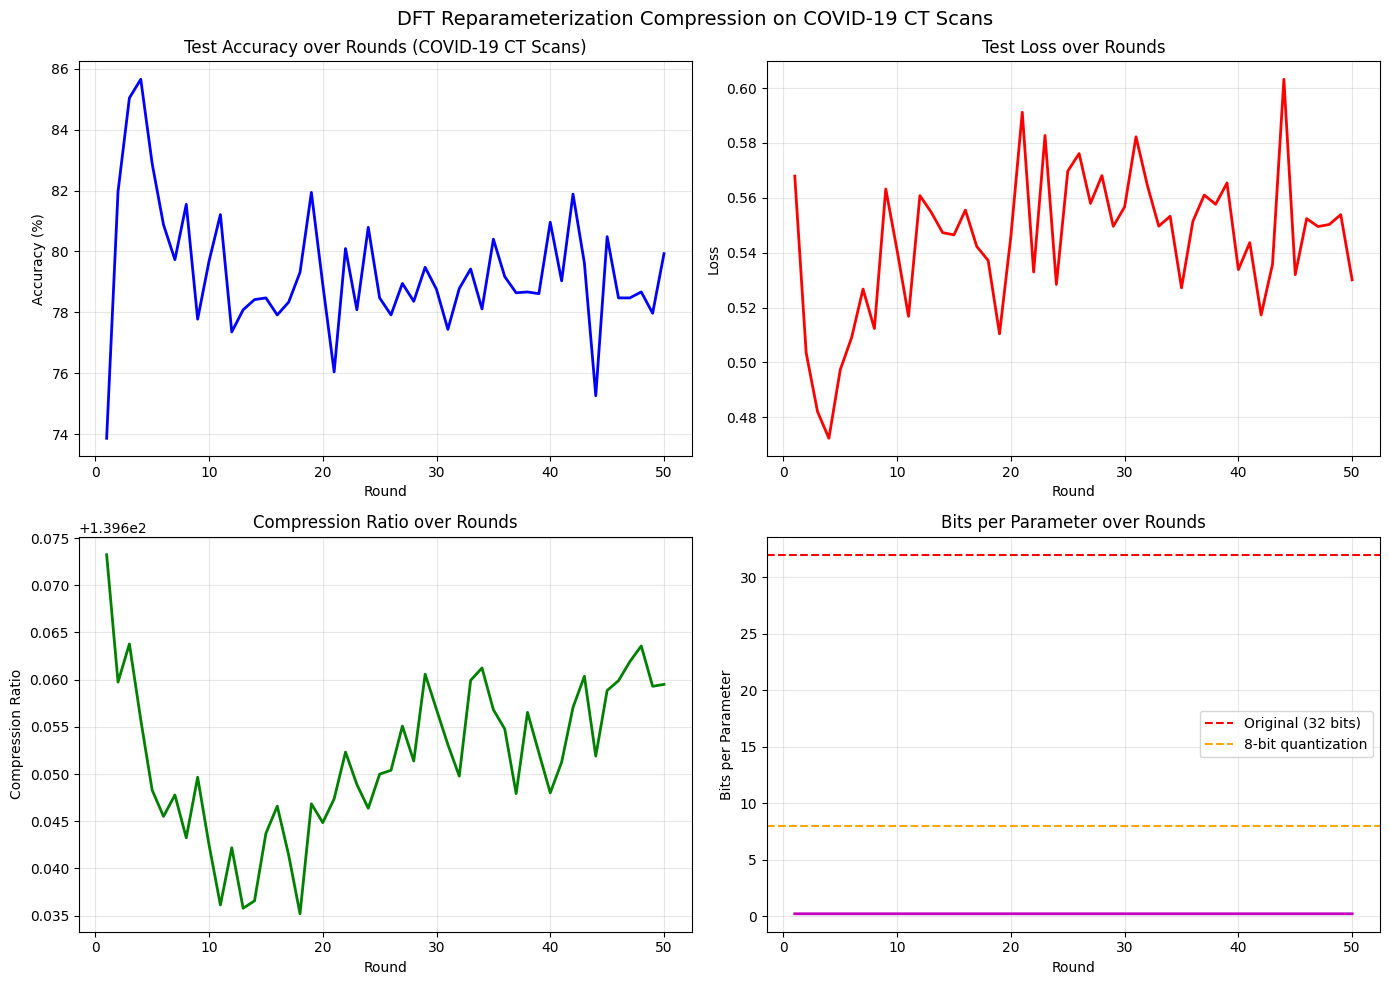

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history['round'], [a*100 for a in history['accuracy']], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Test Accuracy over Rounds (COVID-19 CT Scans)')
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history['round'], history['loss'], 'r-', linewidth=2)
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Test Loss over Rounds')
axes[0, 1].grid(True, alpha=0.3)

# Compression ratio
axes[1, 0].plot(history['round'], history['compression_ratio'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Compression Ratio')
axes[1, 0].set_title('Compression Ratio over Rounds')
axes[1, 0].grid(True, alpha=0.3)

# Bits per parameter
axes[1, 1].plot(history['round'], history['bits_per_param'], 'm-', linewidth=2)
axes[1, 1].axhline(y=32, color='r', linestyle='--', label='Original (32 bits)')
axes[1, 1].axhline(y=8, color='orange', linestyle='--', label='8-bit quantization')
axes[1, 1].set_xlabel('Round')
axes[1, 1].set_ylabel('Bits per Parameter')
axes[1, 1].set_title('Bits per Parameter over Rounds')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('DFT Reparameterization Compression on COVID-19 CT Scans', fontsize=14)
plt.tight_layout()
plt.savefig('dft_covid19_results.png', dpi=150)
plt.show()

## 10. Final Results and Comparison

In [17]:
print("\n" + "="*70)
print("FINAL RESULTS - DFT REPARAMETERIZATION ON COVID-19 CT SCANS")
print("="*70)

final_loss, final_acc = evaluate_model(global_model, x_test_combined, y_test_combined)
final_compression = estimate_entropy_coding_size(global_model)

print(f"\nModel Performance:")
print(f"  - Final Accuracy: {final_acc*100:.2f}%")
print(f"  - Final Loss: {final_loss:.4f}")

print(f"\nCompression Results:")
print(f"  - Compression Ratio: {final_compression['compression_ratio']:.2f}x")
print(f"  - Bits per Parameter: {final_compression['bits_per_param']:.2f}")
print(f"  - Bandwidth Reduction: {(1 - 1/final_compression['compression_ratio'])*100:.1f}%")
print(f"  - Original Size: {final_compression['original_size_kb']:.2f} KB")
print(f"  - Compressed Size: {final_compression['compressed_size_kb']:.2f} KB")


FINAL RESULTS - DFT REPARAMETERIZATION ON COVID-19 CT SCANS

Model Performance:
  - Final Accuracy: 79.93%
  - Final Loss: 0.5301

Compression Results:
  - Compression Ratio: 139.66x
  - Bits per Parameter: 0.23
  - Bandwidth Reduction: 99.3%
  - Original Size: 2451.38 KB
  - Compressed Size: 17.55 KB


In [18]:
print("\n" + "="*70)
print("COMPARISON: DFT vs YOUR ENTROPY-PENALIZED APPROACH")
print("="*70)

# Your approach results (from FL_MTKD_with_compression.ipynb)
your_accuracy = 83.11
your_compression = 3.94
your_bandwidth_reduction = 72.9

# DFT results
dft_accuracy = final_acc * 100
dft_compression = final_compression['compression_ratio']
dft_bandwidth_reduction = (1 - 1/dft_compression) * 100

print(f"\n{'Metric':<25} {'Your Approach':<20} {'DFT Approach':<20} {'Winner':<15}")
print("-" * 80)

# Accuracy comparison
acc_winner = "Your Approach" if your_accuracy > dft_accuracy else ("DFT" if dft_accuracy > your_accuracy else "Tie")
print(f"{'Accuracy (%)':<25} {your_accuracy:<20.2f} {dft_accuracy:<20.2f} {acc_winner:<15}")

# Compression comparison
comp_winner = "DFT" if dft_compression > your_compression else ("Your Approach" if your_compression > dft_compression else "Tie")
print(f"{'Compression Ratio':<25} {your_compression:<20.2f}x {dft_compression:<20.2f}x {comp_winner:<15}")

# Bandwidth reduction
bw_winner = "DFT" if dft_bandwidth_reduction > your_bandwidth_reduction else "Your Approach"
print(f"{'Bandwidth Reduction (%)':<25} {your_bandwidth_reduction:<20.1f} {dft_bandwidth_reduction:<20.1f} {bw_winner:<15}")

print("\n" + "="*70)
print("SUMMARY:")
print("="*70)
print(f"\nYour Entropy-Penalized Approach:")
print(f"  - Accuracy: {your_accuracy:.2f}%")
print(f"  - Compression: {your_compression:.2f}x")
print(f"  - Bandwidth Reduction: {your_bandwidth_reduction:.1f}%")

print(f"\nDFT Reparameterization Approach:")
print(f"  - Accuracy: {dft_accuracy:.2f}%")
print(f"  - Compression: {dft_compression:.2f}x")
print(f"  - Bandwidth Reduction: {dft_bandwidth_reduction:.1f}%")


COMPARISON: DFT vs YOUR ENTROPY-PENALIZED APPROACH

Metric                    Your Approach        DFT Approach         Winner         
--------------------------------------------------------------------------------
Accuracy (%)              83.11                79.93                Your Approach  
Compression Ratio         3.94                x 139.66              x DFT            
Bandwidth Reduction (%)   72.9                 99.3                 DFT            

SUMMARY:

Your Entropy-Penalized Approach:
  - Accuracy: 83.11%
  - Compression: 3.94x
  - Bandwidth Reduction: 72.9%

DFT Reparameterization Approach:
  - Accuracy: 79.93%
  - Compression: 139.66x
  - Bandwidth Reduction: 99.3%


In [20]:
# Save results
import json

results = {
    'dataset': 'COVID-19_CT_scans',
    'method': 'DFT_reparameterization',
    'final_accuracy': float(final_acc),
    'final_loss': float(final_loss),
    'compression_ratio': float(final_compression['compression_ratio']),
    'bits_per_param': float(final_compression['bits_per_param']),
    'bandwidth_reduction': float(dft_bandwidth_reduction),
    'comparison': {
        'your_approach': {
            'accuracy': your_accuracy,
            'compression_ratio': your_compression,
            'bandwidth_reduction': your_bandwidth_reduction
        },
        'dft_approach': {
            'accuracy': dft_accuracy,
            'compression_ratio': dft_compression,
            'bandwidth_reduction': dft_bandwidth_reduction
        }
    },
    'config': {
        'image_size': IMAGE_SIZE,
        'lambda_rate': LAMBDA_RATE,
        'temperature': TEMPERATURE,
        'alpha': ALPHA,
        'num_rounds': NUM_ROUNDS,
        'num_clients': NUM_CLIENTS
    },
    'history': history
}

with open('dft_covid19_results.json', 'w') as f:
    json.dump(results, f, indent=2)

global_model.save_weights('dft_covid19_model_weights.weights.h5')

print("\nResults saved to:")
print("  - dft_covid19_results.json")
print("  - dft_covid19_model_weights.h5")
print("  - dft_covid19_results.png")


Results saved to:
  - dft_covid19_results.json
  - dft_covid19_model_weights.h5
  - dft_covid19_results.png
